# Final Project

Ok, so today we'll be working with the transactions, product, and hh_demographic tables in the project_data folder.

* First, read in the transactions data.

* Read in the only columns `household_key`, `BASKET_ID`, `DAY`, `PRODUCT_ID`, `QUANTITY`, and `SALES_VALUE`.

* Convert `DAY`, `QUANTITY`, and `PRODUCT_ID` to the smallest appropriate integer types.


In [1]:
import pandas as pd
import numpy as np

In [10]:
transactions = pd.read_csv(
    'project_transactions.csv'
    )

In [11]:
transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int64  
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(7)
memory usage: 180.1 MB


In [14]:
cols = ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE']

transactions.loc[:, cols].describe(include='all').round()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
count,2146311.0,2.146311e+06,2146311.0,2146311.0,2146311.0,2146311.0
mean,1056.0,3.404897e+10,390.0,2884715.0,101.0,3.0
std,605.0,4.723748e+09,190.0,3831949.0,1152.0,4.0
min,1.0,2.698490e+10,1.0,25671.0,0.0,0.0
25%,548.0,3.040798e+10,229.0,917231.0,1.0,1.0
50%,1042.0,3.281176e+10,392.0,1027960.0,1.0,2.0
75%,1581.0,4.012804e+10,555.0,1132771.0,1.0,3.0
max,2099.0,4.230536e+10,711.0,18316298.0,89638.0,840.0


In [15]:
transactions = transactions.astype(
    {
        'DAY' : 'int16',
        'QUANTITY' : 'int32',
        'PRODUCT_ID' : 'int32',
    }
)

In [16]:
transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int32  
 4   QUANTITY           int32  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int64  
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int16(1), int32(2), int64(4)
memory usage: 151.5 MB


In [17]:
# Use the following snippet to create a Date Column.

transactions = (
    transactions
    .assign(date = (pd.to_datetime("2016", format='%Y') 
                    + pd.to_timedelta(transactions["DAY"].sub(1).astype(str) + " days"))
           )
    .drop(["DAY"], axis=1)
)

In [18]:
transactions.head()

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,date
0,1364,26984896261,842930,1,2.19,31742,0.00,1,0.0,0.0,2016-01-01
1,1364,26984896261,897044,1,2.99,31742,-0.40,1,0.0,0.0,2016-01-01
2,1364,26984896261,920955,1,3.09,31742,0.00,1,0.0,0.0,2016-01-01
3,1364,26984896261,937406,1,2.50,31742,-0.99,1,0.0,0.0,2016-01-01
4,1364,26984896261,981760,1,0.60,31742,-0.79,1,0.0,0.0,2016-01-01


## TIME BASED ANALYSIS

* Plot the sum of sales by month. Are sales growing over time?
* Next, plot the same series after filtering down to dates April 2016 and October 2017.
* Then, plot the sum of monthly sales in 2016 vs the monthly sales 2017.
* Finally, plot total sales by day of week.

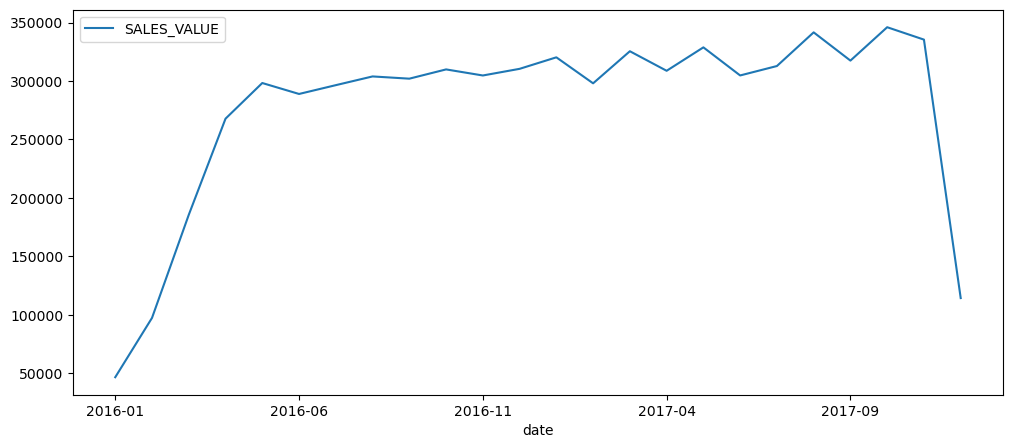

In [37]:
transactions.pivot_table(
    index= transactions['date'].dt.strftime('%Y-%m'),
    values='SALES_VALUE',
    aggfunc='sum'
).plot(figsize = (12,5));

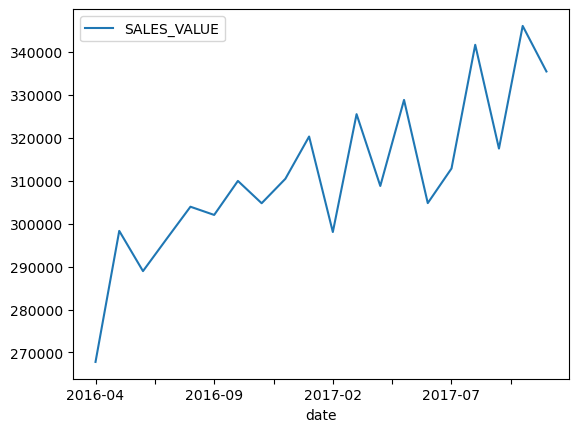

In [92]:
transactions.pivot_table(
    index= transactions['date'].dt.strftime('%Y-%m'),
    values='SALES_VALUE',
    aggfunc='sum'
).query("date >= '2016-04' and date <= '2017-11'").plot();

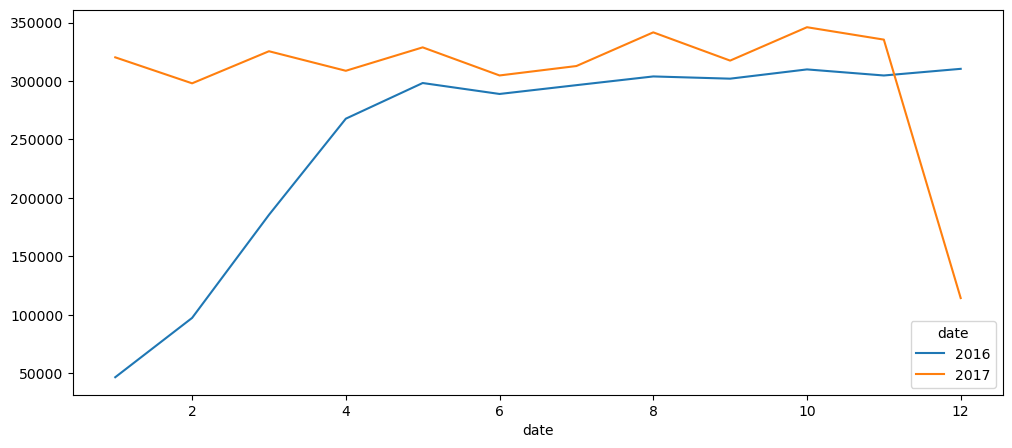

In [35]:
transactions.pivot_table(
    index=transactions['date'].dt.month,
    columns=transactions['date'].dt.year,
    values='SALES_VALUE',
    aggfunc='sum'
).plot(figsize=(12,5));

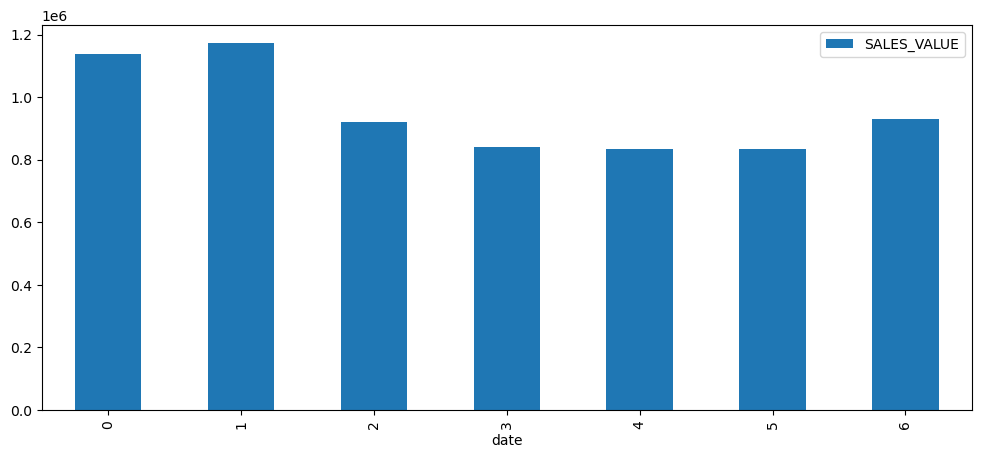

In [93]:
transactions.pivot_table(
    index=transactions['date'].dt.day_of_week,
    values='SALES_VALUE',
    aggfunc='sum'
).plot.bar(figsize=(12,5));

# DEMOGRAPHICS

* Read in the `hh_demographic.csv` file, but only the columns `AGE_DESC`, `INCOME_DESC`, `household_key`, and `HH_COMP_DESC`. Convert the appropriate columns to the category dtype.


* Then group the transactions table by household_id, and calculate the sum of SALES VALUE by household.


* Once you've done that, join the demographics DataFrame to the aggregated transactions table. Since we're interested in analyzing the demographic data we have, make sure not to include rows from transactions that don't match.


* Plot the sum of sales by age_desc and income_desc (in separate charts).


* Then, create a pivot table of the mean household sales by `AGE_DESC` and `HH_COMP_DESC`. Which of our demographics have the highest average sales?


In [47]:
demographics = pd.read_csv(
    'hh_demographic.csv',
    usecols=['AGE_DESC', 'INCOME_DESC', 'household_key','HH_COMP_DESC']
)

In [49]:
demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   AGE_DESC       801 non-null    object
 1   INCOME_DESC    801 non-null    object
 2   HH_COMP_DESC   801 non-null    object
 3   household_key  801 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 25.2+ KB


In [51]:
demographics = demographics.astype(
    {
        'AGE_DESC': 'category',
        'INCOME_DESC': 'category',
        'HH_COMP_DESC': 'category'
    }
)

In [52]:
demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AGE_DESC       801 non-null    category
 1   INCOME_DESC    801 non-null    category
 2   HH_COMP_DESC   801 non-null    category
 3   household_key  801 non-null    int64   
dtypes: category(3), int64(1)
memory usage: 9.5 KB


In [54]:
hh_sales = transactions.groupby(transactions['household_key']).agg({'SALES_VALUE': 'sum'})

In [56]:
demographics_with_sales = demographics.merge(
    hh_sales,
    how = 'inner',
    left_on = 'household_key',
    right_on = 'household_key'
)

<Axes: xlabel='AGE_DESC'>

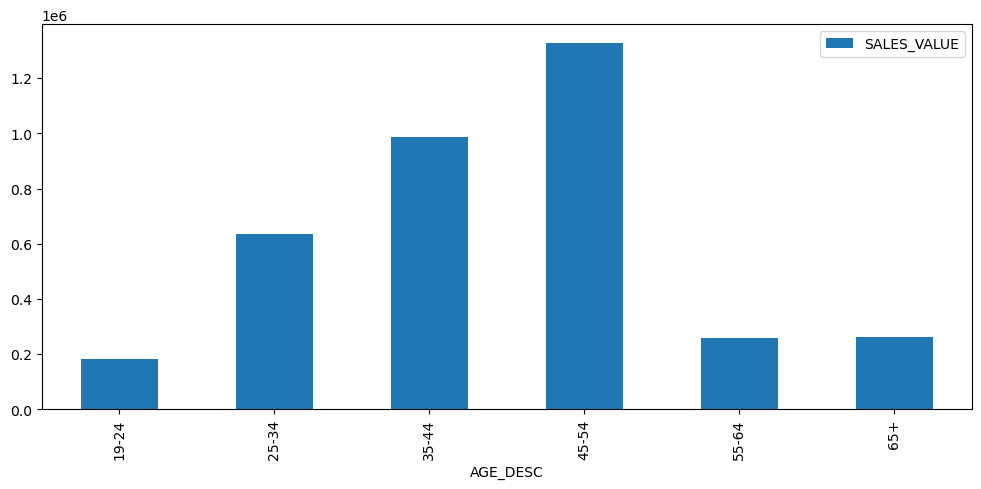

In [94]:
demographics_with_sales.pivot_table(
    index='AGE_DESC',
    values='SALES_VALUE',
    aggfunc='sum'
).plot.bar(figsize=(12,5))

<Axes: xlabel='INCOME_DESC'>

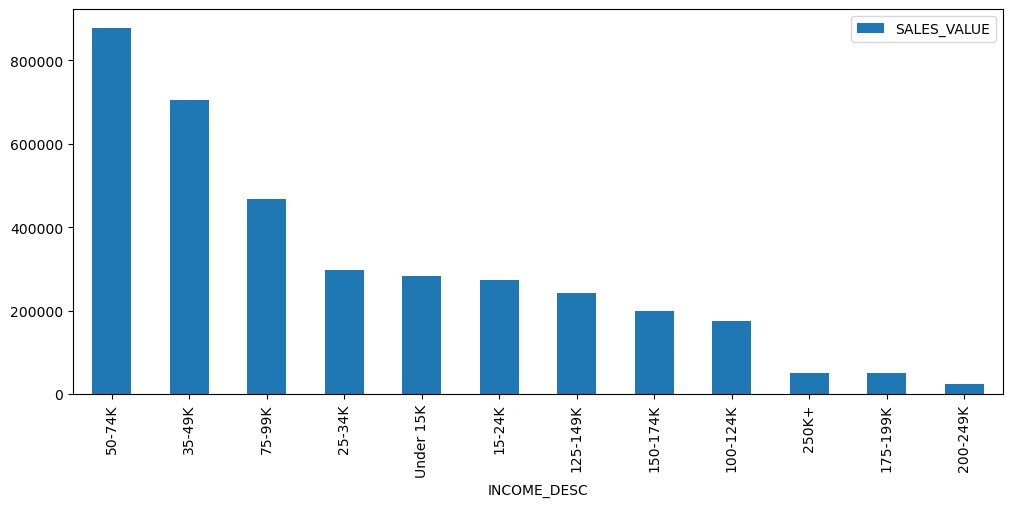

In [65]:
demographics_with_sales.pivot_table(
    index='INCOME_DESC',
    values='SALES_VALUE',
    aggfunc='sum'
).sort_values(by='SALES_VALUE', ascending=False).plot.bar(figsize=(12,5))

In [98]:
demographics_with_sales.pivot_table(
    index = 'AGE_DESC',
    columns = 'HH_COMP_DESC',
    values = 'SALES_VALUE',
    aggfunc = 'mean',
    margins = True
).style.background_gradient(cmap='Greens', axis=None)

HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7268.796667,5428.945000,4020.800000,4576.095556,3216.835000,4911.275000,4692.077692
25-34,5512.196875,5753.973514,5638.515833,4807.440588,4909.522381,7356.270000,5435.517521
35-44,6297.737778,6691.772264,6260.412444,6015.192069,4844.192000,4227.691818,6090.556728
45-54,6632.569167,6610.484490,5839.527027,4549.365405,4636.637083,4843.995682,5534.879958
55-64,3064.870000,4695.655000,5752.413684,4816.148462,3922.546250,7973.750000,5168.924200
65+,4040.810000,5536.866667,4614.108571,4059.699412,3871.556000,2879.290000,4340.936500
All,6032.802143,6280.069103,5599.857756,4895.928361,4544.646750,4936.127778,5468.398743


# PRODUCT DEMOGRAPHICS

* Read in the product csv file.

* Only read in product_id and department from product (consider converting columns).

* Join the product DataFrame to transactions and demographics tables, performing an inner join when joining both tables.

* Finally, pivot the fully joined dataframe by AGE_DESC and DEPARTMENT, calculating the sum of sales. Which category does our youngest demographic perform well in?



In [73]:
products = pd.read_csv(
    'product.csv',
    usecols=['PRODUCT_ID', 'DEPARTMENT'])

In [74]:
products.head()

,PRODUCT_ID,DEPARTMENT
0,25671,GROCERY
1,26081,MISC. TRANS.
2,26093,PASTRY
3,26190,GROCERY
4,26355,GROCERY


In [75]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  92353 non-null  int64 
 1   DEPARTMENT  92353 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.4+ MB


In [76]:
products = products.astype({'DEPARTMENT': 'category'})

In [77]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   PRODUCT_ID  92353 non-null  int64   
 1   DEPARTMENT  92353 non-null  category
dtypes: category(1), int64(1)
memory usage: 813.2 KB


In [81]:
products_with_transactions = products.merge(
    transactions,
    how = 'inner',
    left_on = 'PRODUCT_ID',
    right_on = 'PRODUCT_ID',
)

In [86]:
final_table = products_with_transactions.merge(
    demographics,
    how = 'inner',
    left_on = 'household_key',
    right_on = 'household_key'
)

In [89]:
final_table.pivot_table(
    index = 'DEPARTMENT',
    columns = 'AGE_DESC',
    values = 'SALES_VALUE',
    aggfunc = 'sum'
).style.background_gradient(cmap='Greens', axis=None)

AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AUTOMOTIVE,11.640000,21.250000,72.580000,55.920000,0.000000,16.370000
CHARITABLE CONT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CHEF SHOPPE,81.300000,134.160000,348.530000,418.240000,80.860000,149.240000
CNTRL/STORE SUP,2.000000,0.000000,1.000000,9.950000,2.000000,0.100000
COSMETICS,698.630000,2273.030000,4362.020000,5187.570000,986.260000,600.900000
COUP/STR & MFG,7.490000,48.420000,121.200000,154.550000,40.680000,20.490000
DAIRY DELI,3.800000,3.850000,7.390000,16.750000,3.140000,1.940000
DELI,4043.300000,18181.940000,34577.290000,44334.220000,9850.540000,10462.330000


# EXPORT

Finally, export your pivot table to an excel file. Make sure to provide a sheet name.

In [100]:
(final_table.pivot_table(
    index = 'DEPARTMENT',
    columns = 'AGE_DESC',
    values = 'SALES_VALUE',
    aggfunc = 'sum'
).style.background_gradient(cmap='Greens', axis=None)).to_excel("final_table.xlsx", sheet_name='sales_pivot')